<a href="https://colab.research.google.com/github/eskindir-kibreab/Machine-Learning-Regression-Models-using-House-Price-Dataset/blob/main/House_price_pridiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load data
data = pd.read_csv("Housing Price.csv")
print(data.head())
print(data.info())
print(data.describe())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

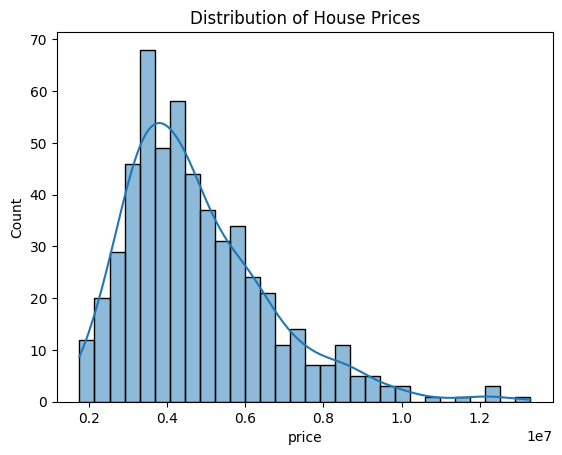

In [5]:
# Visualize target distribution
sns.histplot(data['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

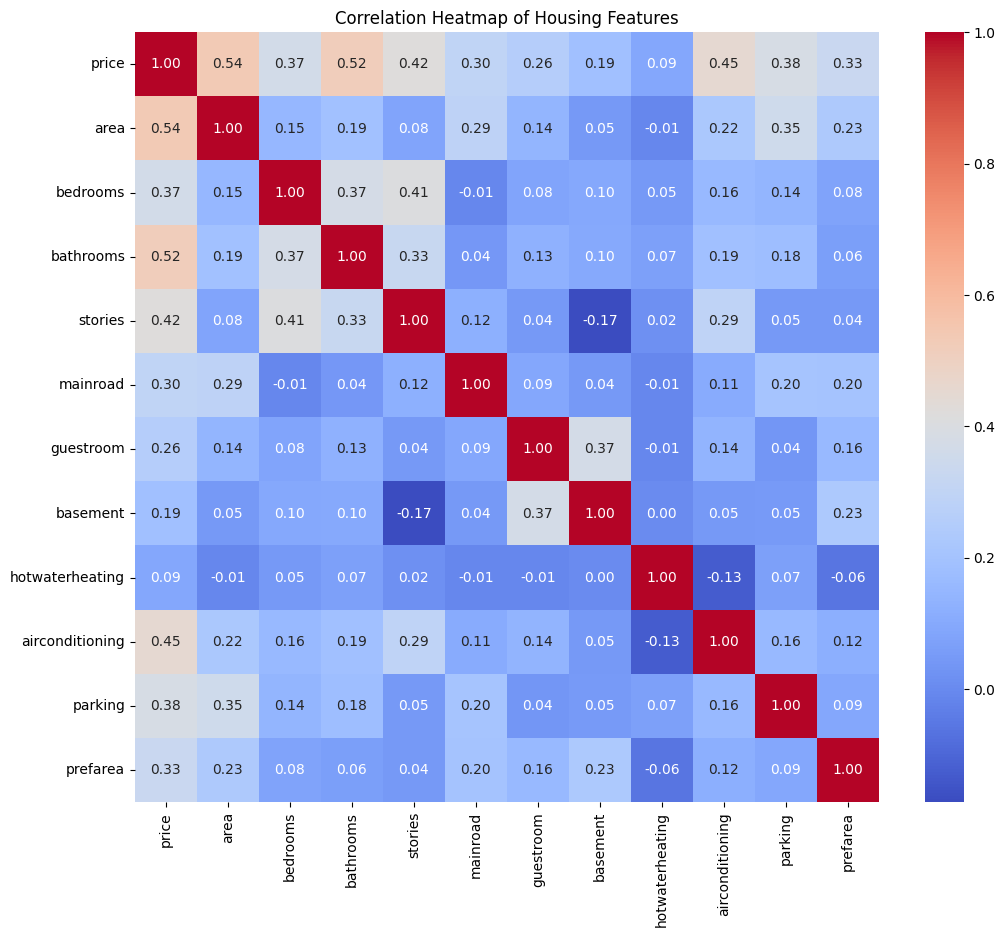

In [7]:
# Correlation heatmap
# Convert binary categorical variables to numerical (0 or 1)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

# Select only numerical columns for correlation, including the newly converted ones
numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Housing Features")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [9]:
# Handle missing values
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [10]:

# Numerical
imputer = SimpleImputer(strategy='median')
data[num_cols] = imputer.fit_transform(data[num_cols])

In [11]:

# Categorical
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

In [12]:
# One-hot encoding
data = pd.get_dummies(data, drop_first=True)

In [14]:
# Features and target
X = data.drop('price', axis=1)
y = data['price']

In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [18]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (Degree 2)": LinearRegression(),
    "KNN Regression": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

In [19]:
# Polynomial features for Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [20]:
results = {}

for name, model in models.items():
    if name == "Polynomial Regression (Degree 2)":
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

# Display results
results_df = pd.DataFrame(results).T
print(results_df)


                                           MAE           MSE          RMSE  \
Linear Regression                 9.700434e+05  1.754319e+12  1.324507e+06   
Polynomial Regression (Degree 2)  1.034749e+06  1.901686e+12  1.379016e+06   
KNN Regression                    9.995946e+05  1.953997e+12  1.397854e+06   
Decision Tree                     1.195266e+06  2.642803e+12  1.625670e+06   

                                        R2  
Linear Regression                 0.652924  
Polynomial Regression (Degree 2)  0.623769  
KNN Regression                    0.613420  
Decision Tree                     0.477146  
